### Zadanie 2

In [95]:
import numpy as np
import sklearn.datasets
from sklearn.datasets import load_wine
from sklearn.datasets import fetch_california_housing
import pandas as pd
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

In [72]:
wines = load_wine()
X, y = wines.data, wines.target
df = pd.DataFrame(X, columns=wines.feature_names)
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
models={
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
}
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    results[name] = {'train_score': train_score, 'test_score': test_score}

results_df = pd.DataFrame(results)
results_df

,Logistic Regression,Decision Tree,KNN
train_score,0.992958,1.000000,0.781690
test_score,0.944444,0.944444,0.805556


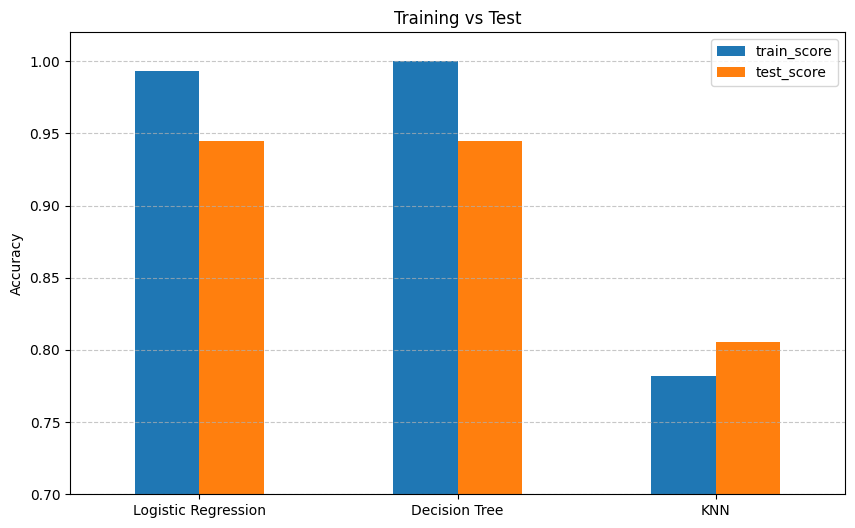

In [74]:
results_df.T.plot(kind='bar', figsize=(10, 6))
plt.title('Training vs Test')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.02)
plt.legend(loc='upper right')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Zadanie 4

In [83]:
housing = fetch_california_housing()
#y2 - mediana wartości domów
X2, y2 = housing.data, housing.target
df2 = pd.DataFrame(X2, columns=housing.feature_names)
df2.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [96]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

scaler = StandardScaler()
X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)

LR_model = LinearRegression().fit(X2_train_scaled, y2_train)

LR_pred_train = LR_model.predict(X2_train_scaled)
LR_pred_test = LR_model.predict(X2_test_scaled)

mse = mean_squared_error(y2_test, LR_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y2_test, LR_pred_test)
print(f'RMSE: {rmse}')
print(f'R2: {r2}')

RMSE: 0.7455813830127763
R2: 0.575787706032451


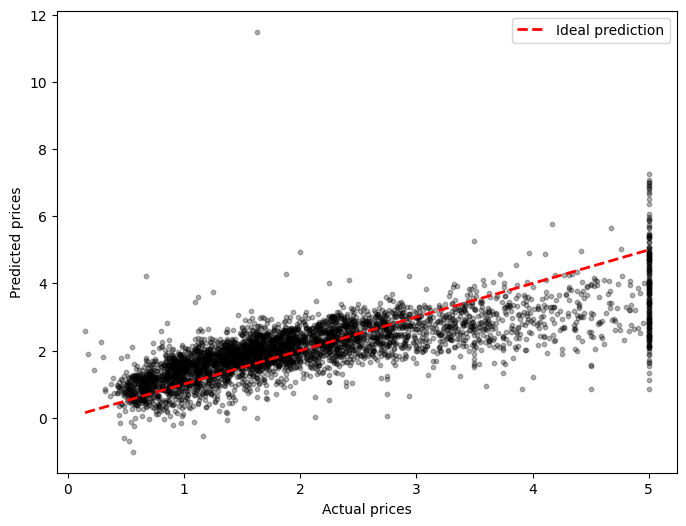

In [107]:
plt.figure(figsize=(8, 6))
plt.scatter(y2_test, LR_pred_test, color='black', alpha=0.3, s=10) # alpha pomaga przy gęstych danych

ideal = [y2_test.min(), y2_test.max()]
plt.plot(ideal, ideal, color='red', linestyle='--', linewidth=2, label='Ideal prediction')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.xlabel('Actual prices')
plt.ylabel('Predicted prices')
plt.legend()
plt.show()